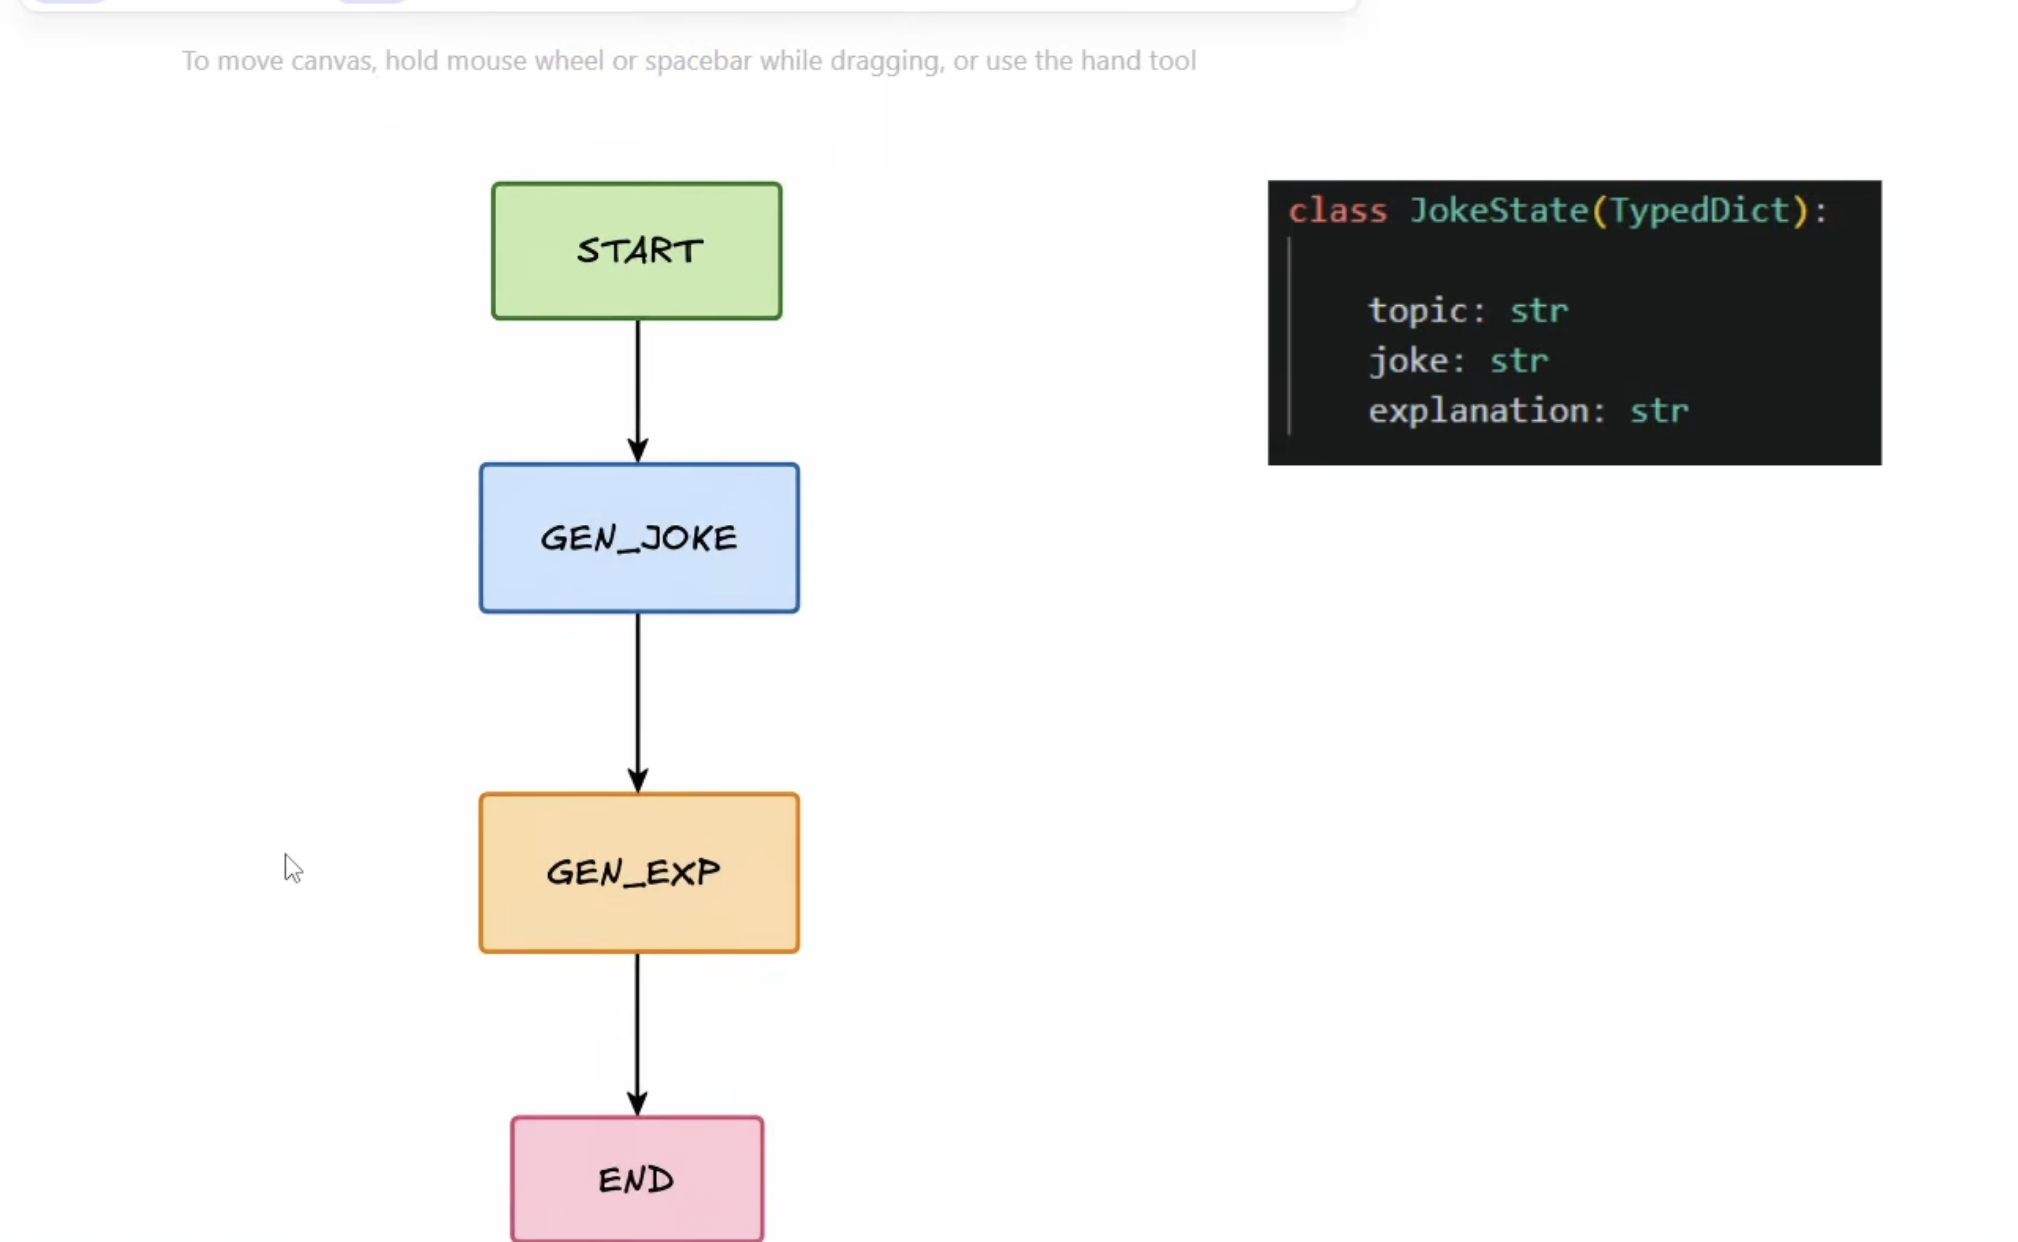

In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import os


In [21]:
load_dotenv()  # Load environment variables from .env file

True

In [29]:
llm = ChatOpenAI(model_name="gpt-5-nano",  
 temperature=0.7,    api_key=os.getenv("OPENAI_API_KEY"))

In [23]:
class JokeState(TypedDict):
    joke: str
    topic: str
    explanation: str

In [24]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [25]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [26]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

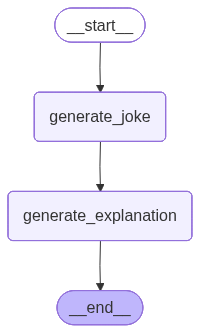

In [27]:
workflow

In [30]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'Football'}, config=config1)

{'joke': 'Here are a few quick football jokes:\n\n- Why did the quarterback bring string to the game? To tie the score.\n- Why did the football team go to the bank? To get their quarterback.\n- Why are stadiums always so cool? They have tons of fans.',
 'topic': 'Football',
 'explanation': 'Here’s a quick breakdown of the wordplay in each joke:\n\n- Why did the quarterback bring string to the game? To tie the score.\n  - The humor comes from a double meaning of “tie.” In football, “tie the score” means both teams have the same score. In everyday language, “tie” also means to fasten something with string. So the quarterback brings string to literally “tie” something, punning on the sports phrase.\n\n- Why did the football team go to the bank? To get their quarterback.\n  - This plays on the two uses of the word “quarterback.” In football, the quarterback is a key player. At a bank, you deal with money, including coins like quarters. The joke pivots on imagining the team going to a bank 

In [39]:
import json
print(workflow.get_state(config1))

StateSnapshot(values={'joke': 'Here are a few quick football jokes:\n\n- Why did the quarterback bring string to the game? To tie the score.\n- Why did the football team go to the bank? To get their quarterback.\n- Why are stadiums always so cool? They have tons of fans.', 'topic': 'Football', 'explanation': 'Here’s a quick breakdown of the wordplay in each joke:\n\n- Why did the quarterback bring string to the game? To tie the score.\n  - The humor comes from a double meaning of “tie.” In football, “tie the score” means both teams have the same score. In everyday language, “tie” also means to fasten something with string. So the quarterback brings string to literally “tie” something, punning on the sports phrase.\n\n- Why did the football team go to the bank? To get their quarterback.\n  - This plays on the two uses of the word “quarterback.” In football, the quarterback is a key player. At a bank, you deal with money, including coins like quarters. The joke pivots on imagining the te

In [46]:
import json, pprint
state_history = list(workflow.get_state_history(config1))
for i, snapshot in enumerate(state_history):
    print(f"--- Snapshot {i} ---")
    print(snapshot)

--- Snapshot 0 ---
StateSnapshot(values={'joke': 'Here are a few quick football jokes:\n\n- Why did the quarterback bring string to the game? To tie the score.\n- Why did the football team go to the bank? To get their quarterback.\n- Why are stadiums always so cool? They have tons of fans.', 'topic': 'Football', 'explanation': 'Here’s a quick breakdown of the wordplay in each joke:\n\n- Why did the quarterback bring string to the game? To tie the score.\n  - The humor comes from a double meaning of “tie.” In football, “tie the score” means both teams have the same score. In everyday language, “tie” also means to fasten something with string. So the quarterback brings string to literally “tie” something, punning on the sports phrase.\n\n- Why did the football team go to the bank? To get their quarterback.\n  - This plays on the two uses of the word “quarterback.” In football, the quarterback is a key player. At a bank, you deal with money, including coins like quarters. The joke pivots 